In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **IMPORTING THE DATASET**

In [2]:
df = pd.read_csv(r"C:\Users\sudhanshu\Downloads\archive\StudentsPerformance.csv")

In [3]:
df.shape

(1000, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## **ADDING THE COLUMNS**

In [6]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('/', '_')

In [7]:
# Average score
df['avarage_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)

# Performance score
def performance_level(score):
    if score <50:
        return 'Low'
    elif score <75:
        return 'Medium'
    else:
        return 'High'

df['performance_level'] = df['avarage_score'].apply(performance_level)

# weak subject
df['weak_subject'] = df[['math_score', 'reading_score', 'writing_score']].idxmin(axis=1)

In [8]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,avarage_score,performance_level,weak_subject
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Medium,math_score
1,female,group C,some college,standard,completed,69,90,88,82.333333,High,math_score
2,female,group B,master's degree,standard,none,90,95,93,92.666667,High,math_score
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Low,writing_score
4,male,group C,some college,standard,none,76,78,75,76.333333,High,writing_score


## **EXPLORATORY DATA ANALYSIS (EDA)**

<function matplotlib.pyplot.show(close=None, block=None)>

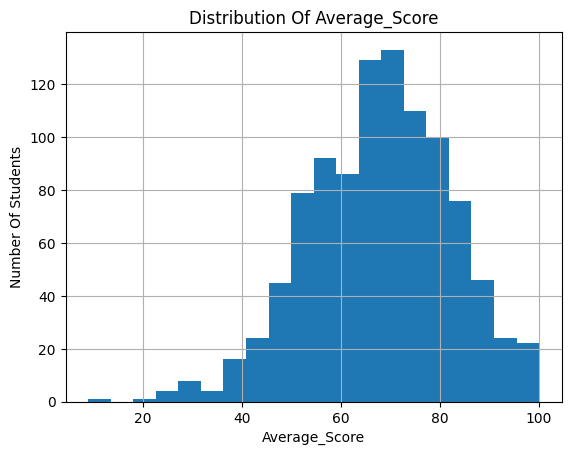

In [9]:
df['avarage_score'].hist(bins=20)
plt.title("Distribution Of Average_Score")
plt.xlabel("Average_Score")
plt.ylabel("Number Of Students")
plt.show

In [10]:
df['weak_subject'].value_counts()

weak_subject
math_score       552
writing_score    292
reading_score    156
Name: count, dtype: int64

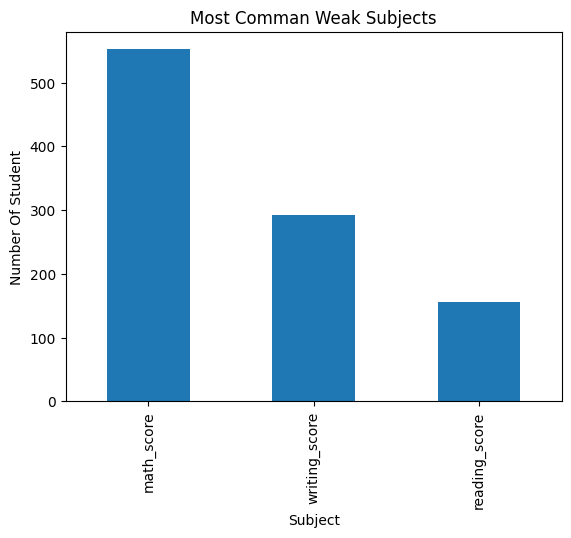

In [11]:
df['weak_subject'].value_counts().plot(kind='bar')
plt.title("Most Comman Weak Subjects")
plt.xlabel("Subject")
plt.ylabel("Number Of Student")
plt.show()

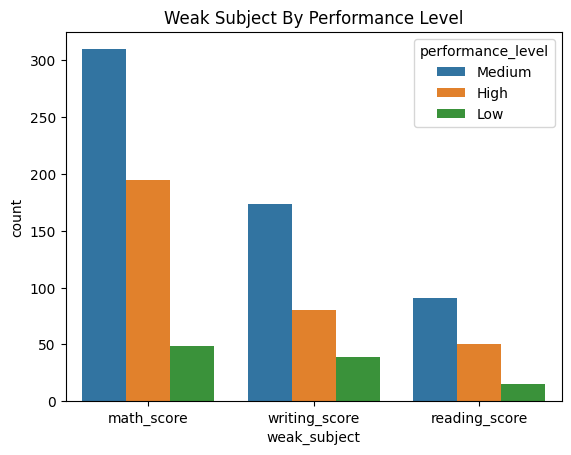

In [12]:
sns.countplot(data=df, x='weak_subject', hue='performance_level')
plt.title("Weak Subject By Performance Level")
plt.show()

## **QUICK ANSWER LOGIC**

In [13]:
def study_recomandation(row):
    if row['performance_level'] == 'Low':
        return f"Focus on basics of {row['weak_subject'].replace(' score','')}. Use Summaries And Flashcards."
    elif row['performance_level'] == 'Medium':
        return f"Practice More Quetions in {row['weak_subject'].replace(' score','')} to improve."
    else:
        return f"Your Strong Overall. Try advanced problems in {row['weak_subject'].replace(' score','')}."

df['study_recomandation'] = df.apply(study_recomandation, axis=1)

In [14]:
df[['avarage_score', 'performance_level', 'weak_subject', 'study_recomandation']].head()

,avarage_score,performance_level,weak_subject,study_recomandation
0,72.666667,Medium,math_score,Practice More Quetions in math_score to improve.
1,82.333333,High,math_score,Your Strong Overall. Try advanced problems in ...
2,92.666667,High,math_score,Your Strong Overall. Try advanced problems in ...
3,49.333333,Low,writing_score,Focus on basics of writing_score. Use Summarie...
4,76.333333,High,writing_score,Your Strong Overall. Try advanced problems in ...


## **STUDENT SNAPSHOT FUNCTION**

In [16]:
def student_quick_view(index):
    row = df.iloc[index]
    return {
        "Average Score": round(row['avarage_score'], 2),
        "Performance Level": row['performance_level'],
        "Weak Subject": row['weak_subject'].replace(' score',''),
        "Instant Advise": row['study_recomandation']
    }

In [17]:
student_quick_view(5)

{'Average Score': np.float64(77.33),
 'Performance Level': 'High',
 'Weak Subject': 'math_score',
 'Instant Advise': 'Your Strong Overall. Try advanced problems in math_score.'}

## **PERFORMANCE LEVEL FROM SCORES**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [19]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'avarage_score', 'performance_level', 'weak_subject',
       'study_recomandation'],
      dtype='object')

In [20]:
x = df[['math_score', 'reading_score', 'writing_score']]
y = df['performance_level']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy_score(y_test, y_pred)

0.97